In [1]:
import pandas as pd

df = pd.read_csv("../data/industrial_motor_sensor_data_8000.csv")

df.head()

,Voltage (V),Current (A),Temperature (°C),Vibration (mm/s),Label
0,460.01,1.79,118.33,22.37,high
1,419.12,15.52,36.93,2.18,normal
2,380.53,30.78,83.08,12.06,moderate
3,382.82,12.50,54.33,4.48,normal
4,333.79,0.96,118.99,24.41,high


## Here we begin a brief exploratory data analysis to validate whether it's worthwhile to proceed with the implementation of machine learning

In [2]:
df["Label"].value_counts()

Label
high        2000
normal      2000
moderate    2000
low         2000
Name: count, dtype: int64

In [3]:
df.describe()

,Voltage (V),Current (A),Temperature (°C),Vibration (mm/s)
count,8000.000000,8000.000000,8000.000000,8000.000000
mean,382.502995,18.368696,67.222605,10.586649
std,56.219001,12.558719,26.281466,9.655103
min,200.260000,0.000000,30.010000,0.000000
25%,356.470000,10.610000,44.757500,2.530000
50%,390.545000,15.600000,60.245000,5.070000
75%,410.480000,26.962500,89.987500,19.995000
max,479.970000,49.990000,119.980000,29.990000


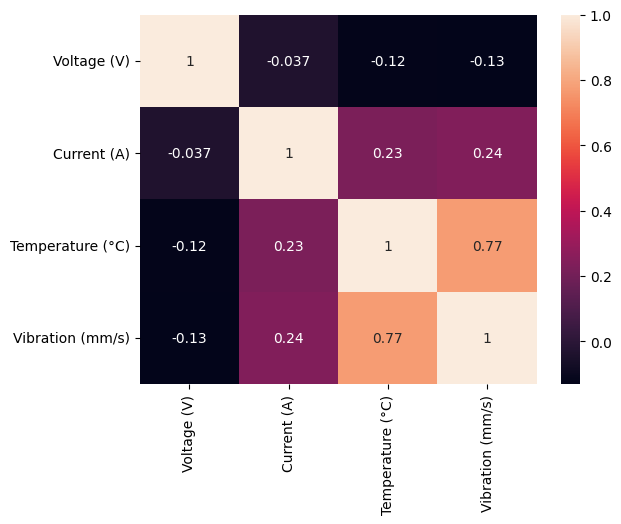

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.drop("Label", axis=1).corr(),
            annot=True)

plt.show()

<Axes: xlabel='Label', ylabel='Temperature (°C)'>

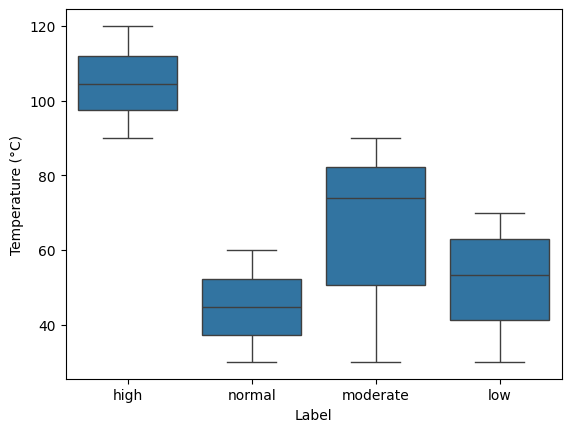

In [5]:
sns.boxplot(
    x="Label",
    y="Temperature (°C)",
    data=df
)

<Axes: xlabel='Label', ylabel='Current (A)'>

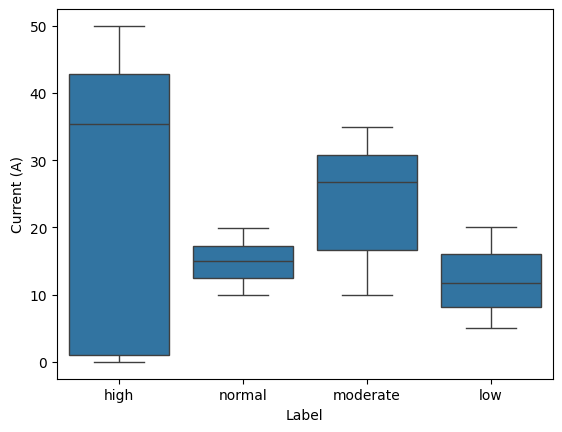

In [6]:
sns.boxplot(
    x="Label",
    y="Current (A)",
    data=df
)

<Axes: xlabel='Label', ylabel='Voltage (V)'>

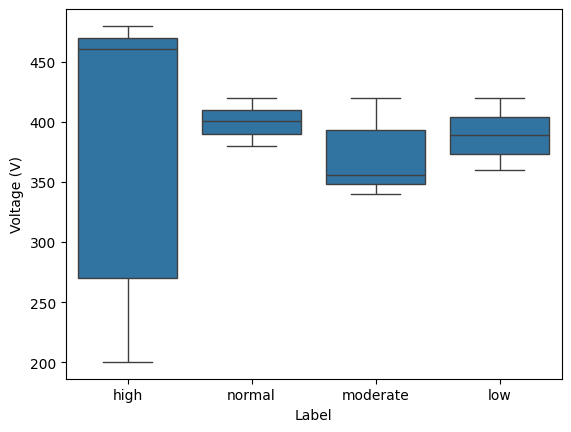

In [7]:
sns.boxplot(
    x="Label",
    y="Voltage (V)",
    data=df
)

<Axes: xlabel='Label', ylabel='Vibration (mm/s)'>

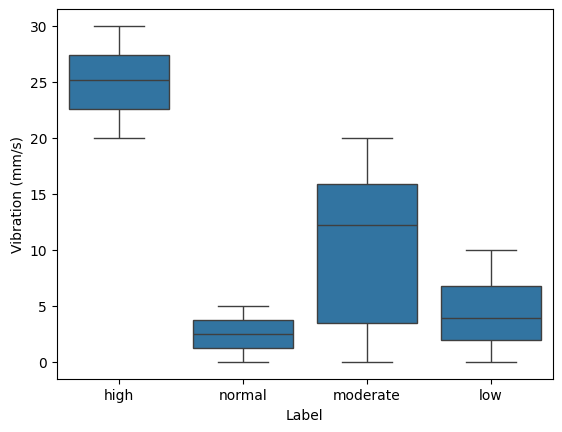

In [8]:
sns.boxplot(
    x="Label",
    y="Vibration (mm/s)",
    data=df
)

## Preparing the data for modeling and starting the training.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Label", axis=1)
y = df["Label"]  

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  
)

y_train.value_counts()

Label
moderate    1600
low         1600
normal      1600
high        1600
Name: count, dtype: int64

## RandomForest Application

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

        high       1.00      1.00      1.00       400
         low       1.00      1.00      1.00       400
    moderate       1.00      1.00      1.00       400
      normal       1.00      1.00      1.00       400

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



## Logistic Regression Application

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print(classification_report(y_test, pred_lr))

              precision    recall  f1-score   support

        high       1.00      1.00      1.00       400
         low       0.82      0.80      0.81       400
    moderate       0.97      0.96      0.97       400
      normal       0.82      0.85      0.84       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



c:\Users\USER\Documents\precditive-model-industrial\env_ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# In this section, we will create the first model using XGBoost.

XGBoost does not accept text classes, so we need a `LabelEncoder` - but scoped **only in this section**, to variables with proper names (`y_train_enc`, `y_test_enc`), so as not to overwrite the `y_train`/`y_test` text used by the other models.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

le = LabelEncoder()
le.fit(y)  
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

print("Mapeamento:", dict(zip(le.classes_, le.transform(le.classes_))))

xgb = XGBClassifier(random_state=42, eval_metric="logloss")
xgb.fit(X_train, y_train_enc)

pred_xgb = le.inverse_transform(xgb.predict(X_test))  

print(classification_report(y_test, pred_xgb))

Mapeamento: {'high': np.int64(0), 'low': np.int64(1), 'moderate': np.int64(2), 'normal': np.int64(3)}
              precision    recall  f1-score   support

        high       1.00      1.00      1.00       400
         low       1.00      0.99      1.00       400
    moderate       1.00      1.00      1.00       400
      normal       1.00      1.00      1.00       400

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



# This section shows the measured comparison results to understand which model performed best.

## Comparative Table

In [ ]:
import pandas as pd

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    )
}

results = []

for name, model in models.items():

    if name == "XGBoost":
        
        model.fit(X_train, y_train_enc)
        pred = le.inverse_transform(model.predict(X_test))
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(
            y_test,
            pred,
            average="weighted"
        ),
        "Recall": recall_score(
            y_test,
            pred,
            average="weighted"
        ),
        "F1": f1_score(
            y_test,
            pred,
            average="weighted"
        )
    })

benchmark = pd.DataFrame(results)

benchmark.sort_values(
    "F1",
    ascending=False
)

c:\Users\USER\Documents\precditive-model-industrial\env_ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000
3,XGBoost,0.998125,0.998127,0.998125,0.998125
0,Logistic Regression,0.903125,0.903489,0.903125,0.903209


# Cross Validation

In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_enc = le.transform(y)  # versão numérica do y completo, usada só para o XGBoost

for name, model in models.items():

    target = y_enc if name == "XGBoost" else y

    score = cross_val_score(
        model,
        X,
        target,
        cv=cv,
        scoring="f1_weighted"
    )

    print(
        f"{name}: "
        f"{score.mean():.4f} "
        f"(± {score.std():.4f})"
    )

c:\Users\USER\Documents\precditive-model-industrial\env_ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\USER\Documents\precditive-model-industrial\env_ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
 

Logistic Regression: 0.8926 (± 0.0079)
Decision Tree: 0.9991 (± 0.0012)
Random Forest: 0.9997 (± 0.0003)
XGBoost: 0.9986 (± 0.0008)


# Visual Benchmark

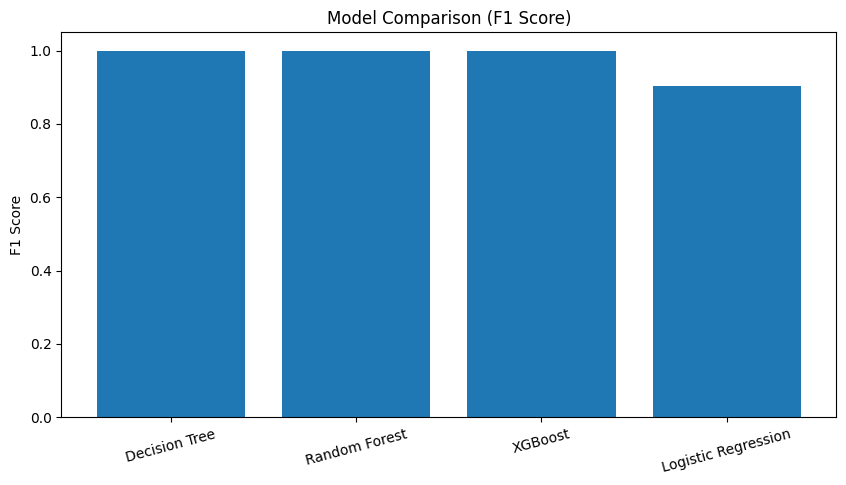

In [15]:
import matplotlib.pyplot as plt

benchmark = benchmark.sort_values(
    "F1",
    ascending=False
)

plt.figure(figsize=(10,5))

plt.bar(
    benchmark["Model"],
    benchmark["F1"]
)

plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")

plt.xticks(rotation=15)

plt.show()

In [16]:
benchmark

,Model,Accuracy,Precision,Recall,F1
1,Decision Tree,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000
3,XGBoost,0.997500,0.997509,0.997500,0.997502
0,Logistic Regression,0.901875,0.902181,0.901875,0.901871


## Saving the best model

## Random Forest is the model used in production by the API (loaded from `random_forest.pkl`), so its final training is done here **only once**, in isolation, reusing only the `X_train`/`y_train` in the text defined in the "Preparing the data" section. This avoids redundant retraining and the reference to an undefined `best_model` variable that existed in the previous version.

In [16]:
rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_train, y_train)

print("Classes do modelo final:", rf_final.classes_)
print(classification_report(y_test, rf_final.predict(X_test)))

Classes do modelo final: ['high' 'low' 'moderate' 'normal']
              precision    recall  f1-score   support

        high       1.00      1.00      1.00       400
         low       1.00      1.00      1.00       400
    moderate       1.00      1.00      1.00       400
      normal       1.00      1.00      1.00       400

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600



# Variable Importance

In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_final.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

            Feature  Importance
2  Temperature (°C)    0.349309
3  Vibration (mm/s)    0.311533
1       Current (A)    0.176072
0       Voltage (V)    0.163086


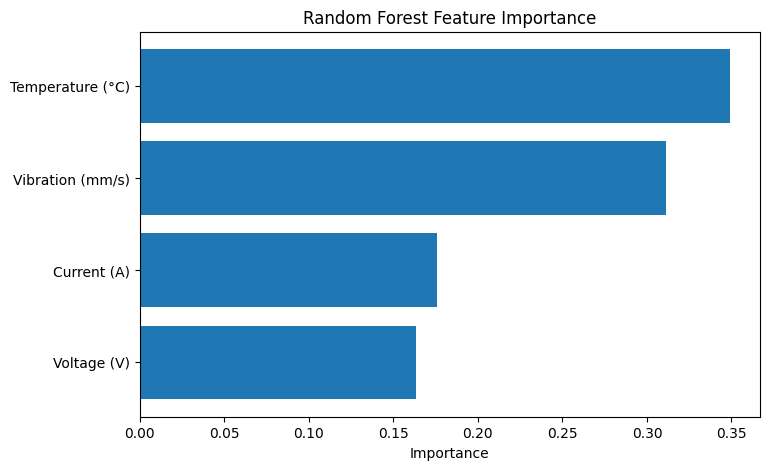

In [18]:
importance_plot = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    importance_plot["Feature"],
    importance_plot["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.show()

# Confusion Matrix

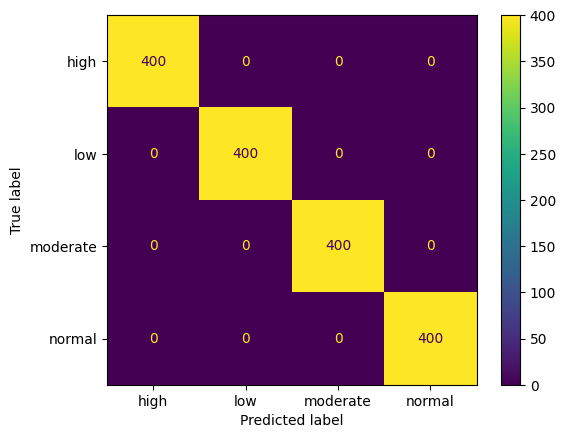

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_final,
    X_test,
    y_test
)

plt.show()

## Interpretability with SHAP

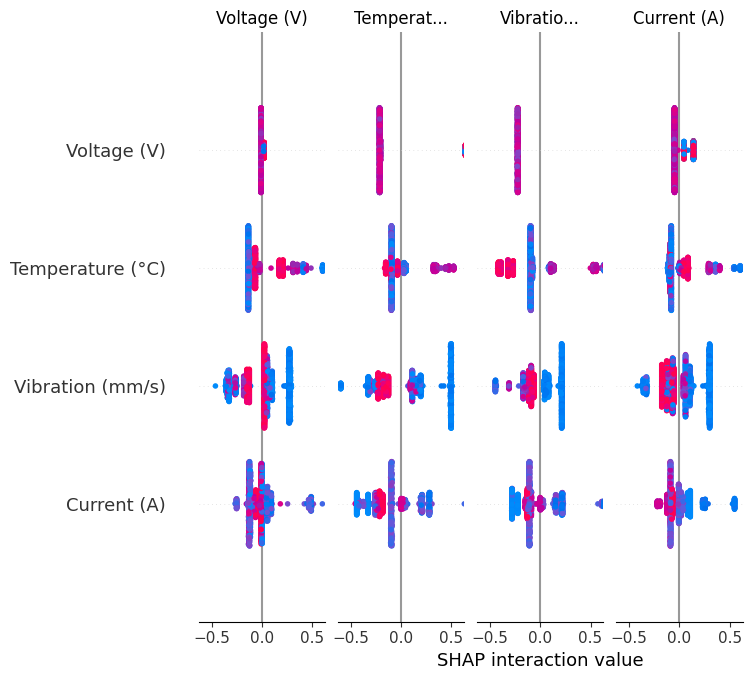

In [20]:
import shap

explainer = shap.TreeExplainer(rf_final)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

In [21]:
import joblib

joblib.dump(
    rf_final,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

## Final Verification

In [22]:
model_check = joblib.load("../models/random_forest.pkl")

amostra = X_test.iloc[[0]]
pred = model_check.predict(amostra)[0]

print("Previsão:", pred, "| tipo:", type(pred))
print("Valor real:", y_test.iloc[0])

Previsão: normal | tipo: <class 'str'>
Valor real: normal
